In [1]:
! pip install ml-collections


[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [2]:
on_colab = False



In [3]:
import os

if not on_colab:
    
    
    root_folder = '../..'

In [4]:
store_attn_on_local: bool = False
store_rel_on_local:  bool = True

In [5]:
if store_attn_on_local or store_rel_on_local:
    if on_colab:
        if os.path.exists('/src/TCT-visual-search/results'):
            os.unlink('/src/TCT-visual-search/results')
        os.symlink(os.path.abspath('../results'), '/src/TCT-visual-search/results')

In [6]:
# _________ APPEND SOME PATH TO IMPORT SOME LIBRARY BELOW _____________
import sys

sys.path.append('..')
sys.path.append('../ViT_utils')
# _________ APPEND SOME PATH TO IMPORT SOME LIBRARY BELOW _____________

In [7]:
import sys
import cv2
import time
from matplotlib import pyplot as plt
from tqdm import tqdm, trange
import numpy as np
import pandas as pd
import pickle
import random
import copy

import os
import shutil
from PIL import Image, ImageDraw
# from google.colab.patches import cv2_imshow

import torch
from torch.utils.data import Dataset
from torchvision.transforms.functional import to_tensor, normalize
from torchvision import transforms

import matplotlib.pyplot as plt
import numpy as np
from scipy.datasets import face
from scipy.ndimage import zoom
from scipy.special import logsumexp
import torch
import deepgaze_pytorch
from deepgaze_pytorch import modules





from coco.dataset import COCODataset
from utils import *
sys.path.append("..")

In [8]:
def logsearchProcess(x, y, tg_xy, attentionMap, image_size, size, coef):
    mask_size = size
    tg_x, tg_y, w, h = tg_xy
    tg_xmax, tg_ymax = tg_x + w, tg_y + h 

    attenNP = (attentionMap[0,:,:].detach() * coef[0,:,:].detach()).numpy()
    y_fix, x_fix = y, x

    x_max_s, x_min_s, y_max_s, y_min_s = min(x_fix+mask_size//2, image_size[1]-1), max(x_fix-mask_size//2, 0), min(y_fix+mask_size//2, image_size[0]-1), max(y_fix-mask_size//2, 0)

    if x_max_s < tg_x or x_min_s > tg_xmax or y_max_s < tg_y or y_min_s > tg_ymax:
        coef[0, y_min_s:y_max_s+1, x_min_s:x_max_s+1] = 1000
        attenNP = (attentionMap[0,:,:].detach() * coef[0,:,:].detach()).numpy()
        y_fix, x_fix = np.unravel_index(attenNP.argmax(), attenNP.shape)
        return False, (x_fix, y_fix), coef

    return True, [], coef

In [9]:

# test_annotations = "../../debug/coco18_test.json"
test_annotations = '../datasets/COCO18_dset_for_CRT_training/coco18_test_deepgaze1.json'
# test_imagedir = "../../coco18_test"
# test_imagedir = '../datasets/COCO18_dset_for_CRT_training/coco18_test_deepgaze/'
test_imagedir = '../datasets/COCO18_dset_for_CRT_training/coco18_test_deepgaze_resize/'

image_list = os.listdir(test_imagedir)
input_images = COCODataset(test_annotations, test_imagedir, image_size=(224,224))

-------------------------------
Annotation Counts
-------------------------------
chair                        43
fork                         41
sink                         51
tv                           50
bowl                         26
car                          20
clock                        23
cup                          49
keyboard                     33
knife                        24
laptop                       23
mouse                        19
oven                         19
potted plant                 28
toilet                       29
bottle                       30
stop sign                    25
microwave                    27
Total                       560
-------------------------------




`coco_search18_fixations_TP_test.json` can be found <a href="https://drive.google.com/drive/folders/1Ic5W67GhqFegQXDO02woLoOWYeC5XgrE">here</a>

In [10]:


coco18_test = "../datasets/COCO18_dset_for_CRT_training/coco_search18_fixations_TP_test.json"

# coco18_test = '../datasets/coco-search18/coco-search18_dataset/processed/human_scanpaths_TP_trainval_valid.json'

df_test = pd.read_json(coco18_test)
df_test.head()

,name,subject,task,condition,bbox,X,Y,T,length,fixOnTarget,correct,split
0,000000394517.jpg,2,bottle,present,"[1348, 559, 142, 395]","[277.6, 364.0, 440.4]","[103.2, 204.3, 208.6]","[203, 79, 178, 294, 372, 362, 184]",3,True,1,test
1,000000276488.jpg,2,bottle,present,"[560, 0, 322, 417]","[258.4, 268.3, 213.4]","[161.8, 138.5, 50.6]","[171, 141, 231, 174, 198]",3,True,1,test
2,000000182213.jpg,2,bottle,present,"[128, 255, 246, 513]","[257.0, 235.7, 161.4, 101.6]","[158.2, 132.7, 127.3, 157.5]","[57, 188, 110, 148, 165, 286, 518]",4,True,1,test
3,000000371864.jpg,2,bottle,present,"[708, 84, 112, 282]","[234.9, 291.7, 251.3, 242.2]","[118.3, 95.9, 82.6, 61.7]","[222, 49, 145, 365, 174, 305, 291, 209, 159]",4,True,1,test
4,000000225129.jpg,2,bottle,present,"[893, 0, 126, 173]","[255.7, 226.5, 289.0]","[154.2, 144.9, 49.4]","[55, 266, 175, 512, 219]",3,True,1,test


In [11]:
df_test[df_test.length == 1]

,name,subject,task,condition,bbox,X,Y,T,length,fixOnTarget,correct,split
326,000000576667.jpg,2,toilet,present,"[857, 678, 465, 354]",[237.0],[211.5],[223],1,False,1,test
394,000000492905.jpg,1,tv,present,"[708, 88, 318, 302]",[267.9],[113.5],"[251, 278, 473]",1,True,1,test
473,000000279850.jpg,1,car,present,"[53, 722, 164, 181]",[252.8],[157.4],[274],1,False,1,test
507,000000287443.jpg,2,chair,present,"[575, 0, 575, 122]",[263.9],[158.0],[515],1,False,0,test
618,000000448897.jpg,1,cup,present,"[172, 0, 249, 277]",[268.8],[142.9],[240],1,False,1,test
...,...,...,...,...,...,...,...,...,...,...,...,...
5950,000000195754.jpg,4,tv,present,"[1155, 338, 234, 227]",[228.4],[156.2],[226],1,False,1,test
5953,000000085940.jpg,4,tv,present,"[170, 317, 428, 343]",[243.6],[141.0],[238],1,False,1,test
5954,000000576070.jpg,4,tv,present,"[1325, 312, 185, 176]",[249.1],[167.2],[229],1,False,1,test
6009,000000044263.jpg,8,tv,present,"[1181, 490, 334, 297]",[258.2],[141.1],[180],1,False,1,test


In [12]:
df_test[(df_test.name=='000000488201.jpg') & (df_test.task == 'tv')]

,name,subject,task,condition,bbox,X,Y,T,length,fixOnTarget,correct,split
368,000000488201.jpg,1,tv,present,"[535, 63, 448, 336]","[300.6, 279.7, 222.1]","[142.4, 141.0, 81.2]","[92, 108, 365, 417]",3,True,1,test
1090,000000488201.jpg,2,tv,present,"[535, 63, 448, 336]","[221.9, 239.0]","[140.0, 96.2]","[244, 236, 215]",2,True,1,test
2370,000000488201.jpg,5,tv,present,"[535, 63, 448, 336]",[190.9],[95.2],"[188, 203, 738]",1,True,1,test
2401,000000488201.jpg,6,tv,present,"[535, 63, 448, 336]","[254.2, 238.2]","[168.5, 106.3]","[198, 317, 221, 580]",2,True,1,test
3025,000000488201.jpg,3,tv,present,"[535, 63, 448, 336]","[244.1, 238.1]","[146.1, 74.7]","[283, 374, 459]",2,True,1,test
5882,000000488201.jpg,10,tv,present,"[535, 63, 448, 336]","[216.7, 216.1]","[132.9, 80.5]","[209, 585]",2,True,1,test
5910,000000488201.jpg,4,tv,present,"[535, 63, 448, 336]","[260.1, 245.4, 232.4]","[147.0, 130.0, 73.7]","[246, 134, 180]",3,True,1,test
6010,000000488201.jpg,8,tv,present,"[535, 63, 448, 336]","[252.3, 239.2]","[138.4, 97.9]","[243, 338, 229]",2,True,1,test
6035,000000488201.jpg,9,tv,present,"[535, 63, 448, 336]","[257.4, 220.6]","[160.5, 89.0]","[78, 311, 235, 180, 28]",2,True,1,test
6094,000000488201.jpg,7,tv,present,"[535, 63, 448, 336]",[258.6],[121.3],"[214, 220, 342]",1,True,1,test


In [13]:
img_size = (320, 512)
tg_bbox_dic, img_initial_fixation = {}, {}
ratio_horizontal, ratio_vertical = 1680/512, 1050/320
# ratio_horizontal, ratio_vertical = 512/512, 320/320

for id in trange(len(input_images)):


    
    _, _, bbox, labels_cpu = input_images[id]
    label_name = input_images.idx2label[labels_cpu]
    
    file_name = input_images.id2file[input_images.annotations[id]['image_id']]
    file_name = file_name.split('/')[-1]
    
    if file_name[:len(label_name)] == label_name:
        file_num = file_name.split('/')[-1][len(label_name):]
    else:
        file_num = file_name.split('/')[-1]
    
    df_select = df_test[(df_test.name==file_num) & (df_test.task == label_name)]

    
    
    choice_list = list(range(len(df_select)))

    k = min(3, len(choice_list))
    
    random_num = random.sample(choice_list, k)
    
    x, y = [], []
    for num in random_num:
        sample = df_select.iloc[num, :]
        x.append(int(sample['X'][0]/ratio_horizontal))
        y.append(int(sample['Y'][0]/ratio_vertical))

    x.append(256)
    y.append(160)

    img_initial_fixation[file_name] = (x, y)

    tg_loc = bbox_cordinates(bbox, img_size[1], img_size[0])
    
    tg_bbox_dic[file_name] = tg_loc

100%|█████████████████████████████████████████████████████████████████████████████████| 560/560 [00:08<00:00, 68.41it/s]


In [14]:

DEVICE = 'mps'
# you can use DeepGazeI or DeepGazeIIE
model = deepgaze_pytorch.DeepGazeIII(pretrained=True).to(DEVICE)
image = face()
centerbias_template = np.load('centerbias_mit1003.npy')
# rescale to match image size
centerbias = zoom(centerbias_template, (image.shape[0]/centerbias_template.shape[0], image.shape[1]/centerbias_template.shape[1]), order=0, mode='nearest')
# renormalize log density
centerbias -= logsumexp(centerbias)
centerbias_tensor = torch.tensor([centerbias], dtype=torch.float32).to(DEVICE)
centerbias_tensor = transforms.Resize(img_size)(centerbias_tensor)










Using cache found in /Users/nguyentuan/.cache/torch/hub/pytorch_vision_v0.6.0
/Users/nguyentuan/Mirror/python_env/FYP_env/lib/python3.11/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Users/nguyentuan/Mirror/python_env/FYP_env/lib/python3.11/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DenseNet201_Weights.IMAGENET1K_V1`. You can also use `weights=DenseNet201_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
/var/folders/ln/xzfjqkm15md4971bjrhc8szr0000gn/T/ipykernel_65098/1553045257.py:10: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray wi

In [15]:
deepgaze3_res, size, scanpath = [], 48, {}
# deepgaze3_res, size, scanpath = [], 1000, {}


for i in trange(len(image_list)):
    # get the target bounding box
    tg_loc = tg_bbox_dic[image_list[i]]
    history_x = img_initial_fixation[image_list[i]][0]
    history_y = img_initial_fixation[image_list[i]][1]

    # get the img path
    img_dir = os.path.join(test_imagedir, image_list[i]) 
    img = cv2.imread(img_dir)

    img_tensor = torch.tensor([img.transpose(2, 0, 1)]).to(DEVICE)
    img_tensor = transforms.Resize(img_size)(img_tensor)

    count, max_search, coef, path = 0, 999, torch.ones((1, 320, 512)), []
    # count, max_search, coef, path = 0, 50, torch.ones((1, 320, 512)), []
    
    
    while count < max_search:
        fixation_history_x = np.array(history_x)
        fixation_history_y = np.array(history_y)
        x_hist_tensor = torch.tensor([fixation_history_x[model.included_fixations]]).to(DEVICE)
        y_hist_tensor = torch.tensor([fixation_history_y[model.included_fixations]]).to(DEVICE)
        log_density_prediction = model(img_tensor, centerbias_tensor, x_hist_tensor, y_hist_tensor)

        path.append([history_x[-1], history_y[-1]])
        isTg, coordinates, coef = logsearchProcess(history_x[-1], history_y[-1], tg_loc, log_density_prediction.squeeze(0).cpu(), img_size, size, coef)
        count += 1

        if isTg: 
            break

        history_x.append(coordinates[0])
        history_y.append(coordinates[1])

    scanpath[image_list[i]] = path

    print(count)
    deepgaze3_res.append(count)


  0%|                                                                                           | 0/560 [00:00<?, ?it/s]/Users/nguyentuan/Mirror/python_env/FYP_env/lib/python3.11/site-packages/torch/functional.py:505: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/native/TensorShape.cpp:4383.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]
  0%|▏                                                                                  | 1/560 [00:02<20:26,  2.19s/it]

4


  0%|▎                                                                                  | 2/560 [00:06<33:21,  3.59s/it]

16


  1%|▍                                                                                  | 3/560 [00:08<27:20,  2.94s/it]

...

4


100%|██████████████████████████████████████████████████████████████████████████████▊| 559/560 [1:06:37<00:04,  4.19s/it]

19


100%|███████████████████████████████████████████████████████████████████████████████| 560/560 [1:06:38<00:00,  7.14s/it]

2


In [16]:
scanpath

{'000000521359.jpg': [[256, 160],
  [np.int64(328), np.int64(172)],
  [np.int64(356), np.int64(156)],
  [np.int64(392), np.int64(88)]],
 '000000336324.jpg': [[256, 160],
  [np.int64(288), np.int64(164)],
  [np.int64(228), np.int64(164)],
  [np.int64(260), np.int64(185)],
  [np.int64(285), np.int64(189)],
  [np.int64(232), np.int64(189)],
  [np.int64(200), np.int64(172)],
  [np.int64(172), np.int64(156)],
  [np.int64(200), np.int64(144)],
  [np.int64(281), np.int64(136)],
  [np.int64(313), np.int64(148)],
  [np.int64(313), np.int64(173)],
  [np.int64(310), np.int64(198)],
  [np.int64(280), np.int64(214)],
  [np.int64(252), np.int64(214)],
  [np.int64(204), np.int64(197)]],
 '000000369185.jpg': [[256, 160],
  [np.int64(276), np.int64(196)],
  [np.int64(301), np.int64(208)],
  [np.int64(388), np.int64(188)],
  [np.int64(413), np.int64(164)],
  [np.int64(248), np.int64(185)],
  [np.int64(188), np.int64(192)]],
 '000000304341.jpg': [[256, 160],
  [np.int64(272), np.int64(204)],
  [np.int64(

In [17]:
deepgaze_res_fig5 = {}
deepgaze_res_fig5['scanpath'] = scanpath
deepgaze_res_fig5['search_list'] = deepgaze3_res

In [18]:
with open("../results/COCO/[Fig5]coco_deepgaze_res.pkl", "wb") as tf:
    pickle.dump(deepgaze_res_fig5, tf)

In [19]:
deepgaze3_accu_coco = [0] + model_performance(deepgaze3_res, len(deepgaze3_res))
deepgaze3_accu_coco[:11]

[0,
 0.0,
 np.float64(0.1357142857142857),
 np.float64(0.21785714285714286),
 np.float64(0.26785714285714285),
 np.float64(0.3),
 np.float64(0.3267857142857143),
 np.float64(0.36607142857142855),
 np.float64(0.4089285714285714),
 np.float64(0.43214285714285716),
 np.float64(0.45)]

In [20]:
with open("../results/coco_deepgaze3_accu_performance.pkl", "wb") as tf:
    pickle.dump(deepgaze3_accu_coco, tf)

<class 'numpy.ndarray'>


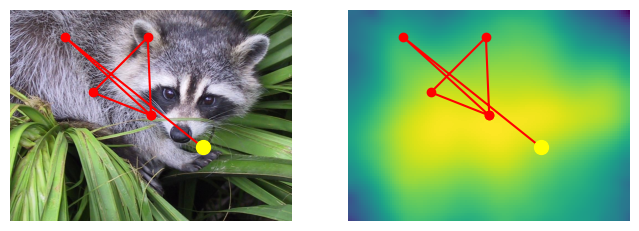

In [32]:
#@title Sample Code { display-mode: "form" }
# location of previous scanpath fixations in x and y (pixel coordinates), starting with the initial fixation on the image.
fixation_history_x = np.array([1024//2, 300, 500, 1024//2, 200, 700])
fixation_history_y = np.array([768//2, 300, 100, 768//2, 100, 500])
x_hist_tensor = torch.tensor([fixation_history_x[model.included_fixations]]).to(DEVICE)
y_hist_tensor = torch.tensor([fixation_history_y[model.included_fixations]]).to(DEVICE)

image = face()
print(type(image))

# load precomputed centerbias log density (from MIT1003) over a 1024x1024 image
# you can download the centerbias from https://github.com/matthias-k/DeepGaze/releases/download/v1.0.0/centerbias_mit1003.npy
# alternatively, you can use a uniform centerbias via `centerbias_template = np.zeros((1024, 1024))`.
centerbias_template = np.load('centerbias_mit1003.npy')
# rescale to match image size
centerbias = zoom(centerbias_template, (image.shape[0]/centerbias_template.shape[0], image.shape[1]/centerbias_template.shape[1]), order=0, mode='nearest')
# renormalize log density
centerbias -= logsumexp(centerbias)
centerbias_tensor = torch.tensor([centerbias], dtype=torch.float32).to(DEVICE)
image_tensor = torch.tensor([image.transpose(2, 0, 1)]).to(DEVICE)

f, axs = plt.subplots(nrows=1, ncols=2, figsize=(8, 3))
axs[0].imshow(image)
axs[0].plot(fixation_history_x, fixation_history_y, 'o-', color='red')
axs[0].scatter(fixation_history_x[-1], fixation_history_y[-1], 100, color='yellow', zorder=100)
axs[0].set_axis_off()

attn_map = log_density_prediction.detach().cpu().numpy()[0, 0]
resized_attn_map = cv2.resize(attn_map, (1024, 768))

axs[1].matshow(resized_attn_map)  # first image in batch, first (and only) channel
axs[1].plot(fixation_history_x, fixation_history_y, 'o-', color='red')
axs[1].scatter(fixation_history_x[-1], fixation_history_y[-1], 100, color='yellow', zorder=100)
axs[1].set_axis_off()